# Week 5 Jupyter Notebook — Support Vector Machines



## Objective

This notebook applies Week 5 Support Vector Machine methods to the flight delay classification problem. I tested a Linear SVM and an RBF kernel SVM to see whether a support vector model could separate delayed and non-delayed flights effectively.

Because SVMs can be slow on large datasets, I used a smaller sample so the notebook could run locally. I also looked at regularization through different values of `C`.


In [19]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")


## 1. Load the datasets

The main modeling data comes from the Kaggle `train.csv` and `test.csv` files. The BTS `Flight_Delay.csv` file is used as supporting context for 2019 delay causes.

SVMs are slower than logistic regression on large datasets, especially when using kernels. Because of that, this notebook uses a smaller sample size so the models can run in a normal Jupyter environment.

In [20]:
# Load data
# Data files are stored in the data folder.

SAMPLE_SIZE = 30000
TEST_SAMPLE_SIZE = 30000
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv", nrows=SAMPLE_SIZE)
test = pd.read_csv("data/test.csv", nrows=TEST_SAMPLE_SIZE)
flight_delay = pd.read_csv("data/Flight_delay.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Flight_Delay shape:", flight_delay.shape)

train.head()


Train shape: (30000, 30)
Test shape: (30000, 30)
Flight_Delay shape: (484551, 29)


,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


## 2. Quick EDA

The target variable is `DEP_DEL15`.

- `0` means the flight was not delayed by at least 15 minutes.
- `1` means the flight was delayed by at least 15 minutes.

This is the same classification target used in Week 4.

Target counts:
DEP_DEL15
0    24332
1     5668
Name: count, dtype: int64

Target percentage:
DEP_DEL15
0    81.11
1    18.89
Name: proportion, dtype: float64


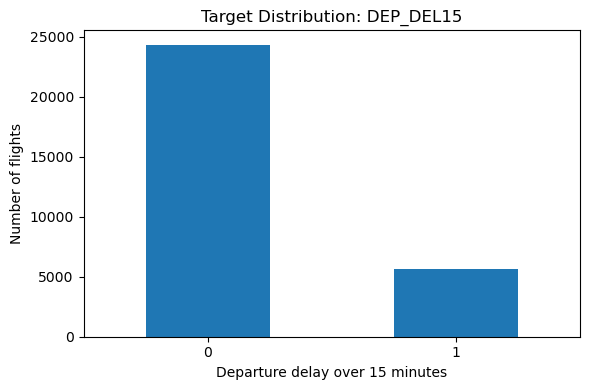


Missing values, top 10:
MONTH                 0
DAY_OF_WEEK           0
DAY_HISTORICAL        0
DEP_AIRPORT_HIST      0
CARRIER_HISTORICAL    0
AWND                  0
TMAX                  0
SNWD                  0
SNOW                  0
PRCP                  0
dtype: int64


In [21]:
target = "DEP_DEL15"

print("Target counts:")
print(train[target].value_counts(dropna=False))

print("\nTarget percentage:")
print((train[target].value_counts(normalize=True, dropna=False) * 100).round(2))

train[target].value_counts().sort_index().plot(kind="bar", figsize=(6, 4))
plt.title("Target Distribution: DEP_DEL15")
plt.xlabel("Departure delay over 15 minutes")
plt.ylabel("Number of flights")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nMissing values, top 10:")
print(train.isna().sum().sort_values(ascending=False).head(10))


BTS total delay minutes by cause:
LateAircraftDelay    12915022
CarrierDelay          8440607
NASDelay              6589613
WeatherDelay          1527927
SecurityDelay           39749
dtype: int64


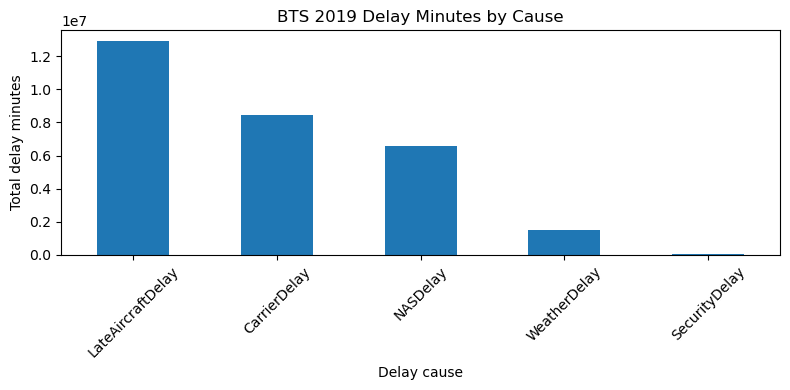

In [22]:
# BTS delay-cause context

bts_delay_cols = [
    "CarrierDelay",
    "WeatherDelay",
    "NASDelay",
    "SecurityDelay",
    "LateAircraftDelay"
]

available_bts_cols = [col for col in bts_delay_cols if col in flight_delay.columns]

if available_bts_cols:
    delay_totals = flight_delay[available_bts_cols].sum().sort_values(ascending=False)

    print("BTS total delay minutes by cause:")
    print(delay_totals)

    delay_totals.plot(kind="bar", figsize=(8, 4))
    plt.title("BTS 2019 Delay Minutes by Cause")
    plt.ylabel("Total delay minutes")
    plt.xlabel("Delay cause")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("BTS delay-cause columns not found. Columns available:")
    print(flight_delay.columns.tolist())


## 3. Select features

For Week 5, I use a smaller feature set than Week 4. This keeps the SVM models easier to run and interpret.

The selected features still represent the main project ideas:

- historical delay risk
- weather
- airport and airline activity
- aircraft and route information
- departure time block

Categorical variables are one-hot encoded. Numeric variables are scaled because SVMs are very sensitive to feature scale.

In [23]:
numeric_candidates = [
    "MONTH",
    "DAY_OF_WEEK",
    "DISTANCE_GROUP",
    "CONCURRENT_FLIGHTS",
    "NUMBER_OF_SEATS",
    "AIRPORT_FLIGHTS_MONTH",
    "AIRLINE_FLIGHTS_MONTH",
    "PLANE_AGE",
    "PRCP",
    "SNOW",
    "SNWD",
    "TMAX",
    "AWND",
    "CARRIER_HISTORICAL",
    "DEP_AIRPORT_HIST",
    "DAY_HISTORICAL",
    "DEP_BLOCK_HIST"
]

categorical_candidates = [
    "DEP_TIME_BLK",
    "CARRIER_NAME"
]

numeric_features = [col for col in numeric_candidates if col in train.columns]
categorical_features = [col for col in categorical_candidates if col in train.columns]

model_data = train[numeric_features + categorical_features + [target]].dropna()

X = model_data[numeric_features + categorical_features]
y = model_data[target].astype(int)

print("Rows used:", X.shape[0])
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Categorical columns used:", categorical_features)


Rows used: 30000
Numeric features: 17
Categorical features: 2
Categorical columns used: ['DEP_TIME_BLK', 'CARRIER_NAME']


## 4. Train/test split

The validation set lets me evaluate the SVM models on data they did not train on. I use `stratify=y` to keep the delayed/not delayed balance similar in both sets.

In [24]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])
print("\nTraining target rate:")
print(y_train.value_counts(normalize=True).round(3))
print("\nValidation target rate:")
print(y_valid.value_counts(normalize=True).round(3))


Training rows: 22500
Validation rows: 7500

Training target rate:
DEP_DEL15
0    0.811
1    0.189
Name: proportion, dtype: float64

Validation target rate:
DEP_DEL15
0    0.811
1    0.189
Name: proportion, dtype: float64


## 5. Preprocessing for SVM

SVMs require feature scaling because they rely on distances and margins. If one variable has a much larger scale than another variable, it can dominate the model.

This is similar to what Week 4 showed with logistic regression, but scaling is even more important for SVMs.

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", max_categories=15), categorical_features)
    ]
)


## 6. Linear SVM

The Linear SVM is the simpler SVM model. It tries to separate delayed and non-delayed flights using a linear decision boundary.

This is useful as a comparison against logistic regression from Week 4 because both are mostly linear classifiers.

In [26]:
linear_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearSVC(C=1.0, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
])

linear_svm.fit(X_train, y_train)

pred_linear = linear_svm.predict(X_valid)
score_linear = linear_svm.decision_function(X_valid)

print("Linear SVM")
print("Accuracy:", round(accuracy_score(y_valid, pred_linear), 4))
print("Precision:", round(precision_score(y_valid, pred_linear), 4))
print("Recall:", round(recall_score(y_valid, pred_linear), 4))
print("F1:", round(f1_score(y_valid, pred_linear), 4))
print("ROC-AUC:", round(roc_auc_score(y_valid, score_linear), 4))

print("\nClassification report:")
print(classification_report(y_valid, pred_linear))


Linear SVM
Accuracy: 0.6241
Precision: 0.2787
Recall: 0.6231
F1: 0.3852
ROC-AUC: 0.6776

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.62      0.73      6083
           1       0.28      0.62      0.39      1417

    accuracy                           0.62      7500
   macro avg       0.58      0.62      0.56      7500
weighted avg       0.76      0.62      0.66      7500



## 7. RBF kernel SVM

The RBF kernel SVM is more flexible than the linear SVM. It can create a nonlinear decision boundary.

This may help because flight delays are likely not caused by one simple linear pattern. Weather, airport congestion, airline history, and time of day may interact in complicated ways.

In [27]:
rbf_svm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE
    ))
])

rbf_svm.fit(X_train, y_train)

pred_rbf = rbf_svm.predict(X_valid)
prob_rbf = rbf_svm.predict_proba(X_valid)[:, 1]

print("RBF Kernel SVM")
print("Accuracy:", round(accuracy_score(y_valid, pred_rbf), 4))
print("Precision:", round(precision_score(y_valid, pred_rbf), 4))
print("Recall:", round(recall_score(y_valid, pred_rbf), 4))
print("F1:", round(f1_score(y_valid, pred_rbf), 4))
print("ROC-AUC:", round(roc_auc_score(y_valid, prob_rbf), 4))

print("\nClassification report:")
print(classification_report(y_valid, pred_rbf))


RBF Kernel SVM
Accuracy: 0.6495
Precision: 0.29
Recall: 0.5907
F1: 0.389
ROC-AUC: 0.6718

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.66      0.75      6083
           1       0.29      0.59      0.39      1417

    accuracy                           0.65      7500
   macro avg       0.58      0.63      0.57      7500
weighted avg       0.76      0.65      0.69      7500



## 8. Compare Linear SVM and RBF SVM

This table compares the simpler linear boundary to the more flexible RBF kernel boundary.

In [28]:
svm_results = pd.DataFrame([
    {
        "Model": "Linear SVM",
        "Accuracy": accuracy_score(y_valid, pred_linear),
        "Precision": precision_score(y_valid, pred_linear),
        "Recall": recall_score(y_valid, pred_linear),
        "F1": f1_score(y_valid, pred_linear),
        "ROC-AUC": roc_auc_score(y_valid, score_linear)
    },
    {
        "Model": "RBF Kernel SVM",
        "Accuracy": accuracy_score(y_valid, pred_rbf),
        "Precision": precision_score(y_valid, pred_rbf),
        "Recall": recall_score(y_valid, pred_rbf),
        "F1": f1_score(y_valid, pred_rbf),
        "ROC-AUC": roc_auc_score(y_valid, prob_rbf)
    }
])

svm_results


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Linear SVM,0.624133,0.278725,0.623147,0.385169,0.677583
1,RBF Kernel SVM,0.649467,0.290021,0.590685,0.389031,0.671831


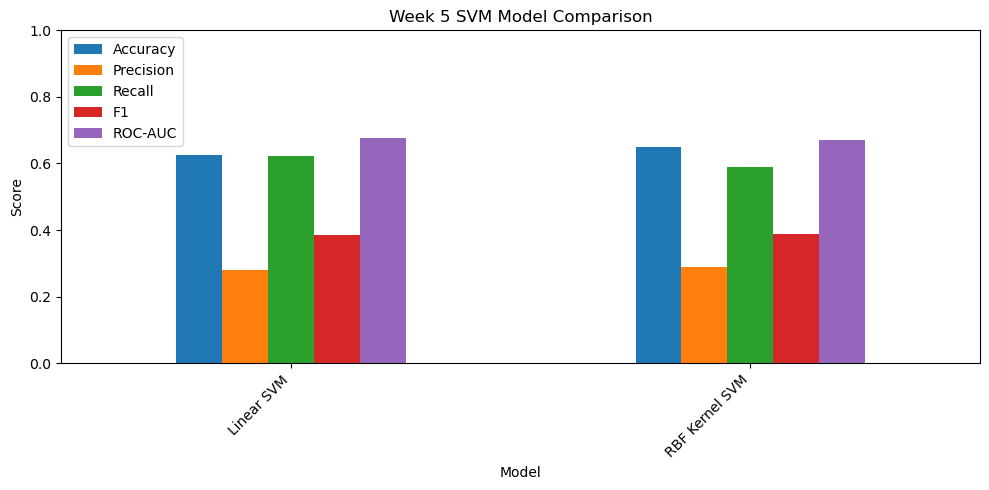

In [29]:
svm_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Week 5 SVM Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 9. Confusion matrix for the best SVM

This section uses F1-score to choose the best SVM from the first comparison. F1 is useful here because it balances precision and recall.

In [30]:
if f1_score(y_valid, pred_rbf) >= f1_score(y_valid, pred_linear):
    best_name = "RBF Kernel SVM"
    best_preds = pred_rbf
    best_scores = prob_rbf
else:
    best_name = "Linear SVM"
    best_preds = pred_linear
    best_scores = score_linear

cm = confusion_matrix(y_valid, best_preds)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Delayed", "Actual Delayed"],
    columns=["Predicted Not Delayed", "Predicted Delayed"]
)

print("Best SVM by F1:", best_name)
cm_df


Best SVM by F1: RBF Kernel SVM


,Predicted Not Delayed,Predicted Delayed
Actual Not Delayed,4034,2049
Actual Delayed,580,837


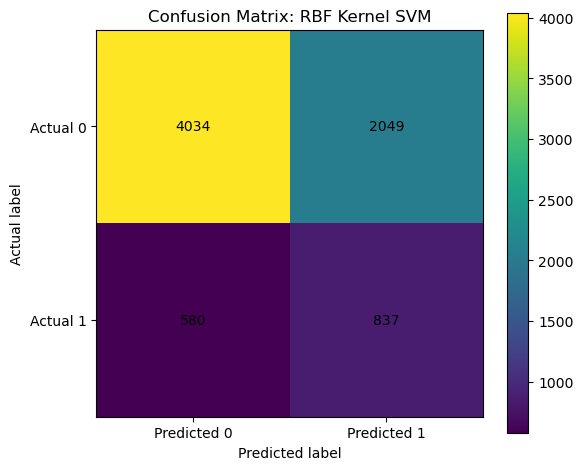

In [31]:
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix: {best_name}")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Predicted 0", "Predicted 1"])
plt.yticks(tick_marks, ["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.ylabel("Actual label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


## 10. ROC curve for the best SVM

The ROC curve shows how well the best SVM separates delayed and non-delayed flights.

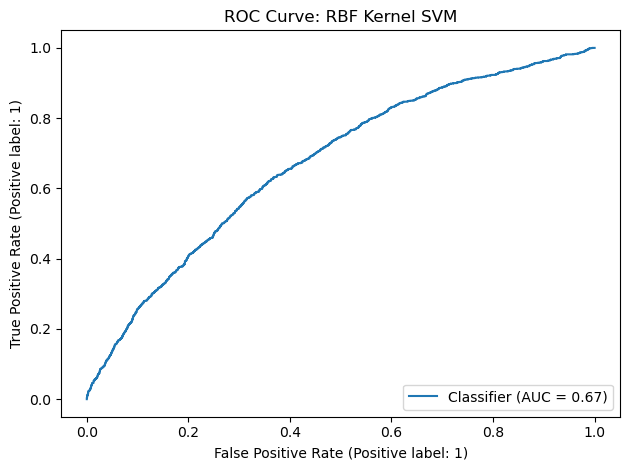

In [32]:
RocCurveDisplay.from_predictions(y_valid, best_scores)
plt.title(f"ROC Curve: {best_name}")
plt.tight_layout()
plt.show()


## 11. SVM regularization with different C values

The `C` value controls regularization in SVMs.

- A **smaller C** allows more mistakes but may generalize better.
- A **larger C** tries harder to correctly classify the training data but may overfit.

This section tests different C values with a Linear SVM because it runs faster than repeatedly fitting RBF SVMs.

In [33]:
c_values = [0.01, 0.1, 1, 10]

c_results = []

for c in c_values:
    svm_c = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearSVC(C=c, class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000))
    ])

    svm_c.fit(X_train, y_train)
    preds_c = svm_c.predict(X_valid)
    scores_c = svm_c.decision_function(X_valid)

    c_results.append({
        "C": c,
        "Accuracy": accuracy_score(y_valid, preds_c),
        "Precision": precision_score(y_valid, preds_c),
        "Recall": recall_score(y_valid, preds_c),
        "F1": f1_score(y_valid, preds_c),
        "ROC-AUC": roc_auc_score(y_valid, scores_c)
    })

c_results_df = pd.DataFrame(c_results)
c_results_df


,C,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.01,0.626267,0.280140,0.623147,0.386518,0.677784
1,0.10,0.624133,0.278725,0.623147,0.385169,0.677612
2,1.00,0.624133,0.278725,0.623147,0.385169,0.677583
3,10.00,0.629733,0.280504,0.613267,0.384939,0.675868


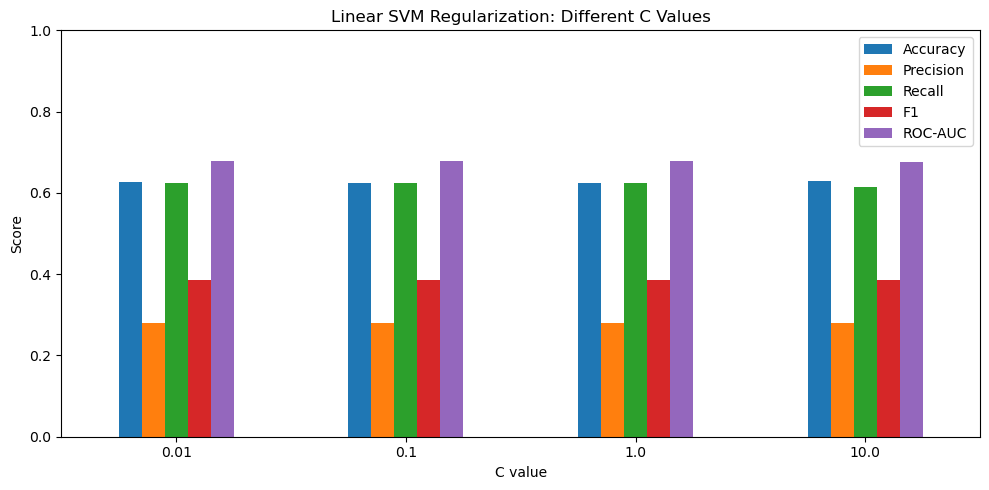

In [34]:
c_results_df.set_index("C")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Linear SVM Regularization: Different C Values")
plt.ylabel("Score")
plt.xlabel("C value")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 12. Week 4 logistic regression comparison

This section keeps the project story connected by comparing the Week 5 SVM results to the Week 4 logistic regression result.

The exact Week 4 result may differ slightly if the sample size changes, but the comparison is still useful. Logistic regression is usually faster and easier to interpret, while SVMs may capture more complex boundaries depending on the kernel.

In [35]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])

logistic_model.fit(X_train, y_train)

pred_log = logistic_model.predict(X_valid)
prob_log = logistic_model.predict_proba(X_valid)[:, 1]

project_comparison = pd.DataFrame([
    {
        "Model": "Scaled Logistic Regression",
        "Accuracy": accuracy_score(y_valid, pred_log),
        "Precision": precision_score(y_valid, pred_log),
        "Recall": recall_score(y_valid, pred_log),
        "F1": f1_score(y_valid, pred_log),
        "ROC-AUC": roc_auc_score(y_valid, prob_log)
    },
    {
        "Model": "Linear SVM",
        "Accuracy": accuracy_score(y_valid, pred_linear),
        "Precision": precision_score(y_valid, pred_linear),
        "Recall": recall_score(y_valid, pred_linear),
        "F1": f1_score(y_valid, pred_linear),
        "ROC-AUC": roc_auc_score(y_valid, score_linear)
    },
    {
        "Model": "RBF Kernel SVM",
        "Accuracy": accuracy_score(y_valid, pred_rbf),
        "Precision": precision_score(y_valid, pred_rbf),
        "Recall": recall_score(y_valid, pred_rbf),
        "F1": f1_score(y_valid, pred_rbf),
        "ROC-AUC": roc_auc_score(y_valid, prob_rbf)
    }
])

project_comparison


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Scaled Logistic Regression,0.626400,0.281201,0.628088,0.388477,0.678512
1,Linear SVM,0.624133,0.278725,0.623147,0.385169,0.677583
2,RBF Kernel SVM,0.649467,0.290021,0.590685,0.389031,0.671831


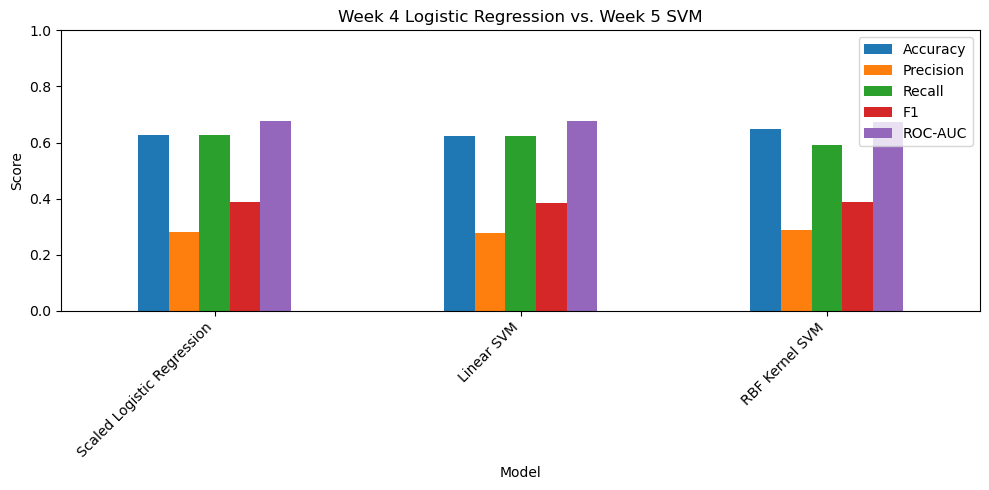

In [36]:
project_comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Week 4 Logistic Regression vs. Week 5 SVM")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Week 5 Conclusion

In this notebook, I tested Support Vector Machine models for predicting whether a flight was delayed. I compared a Linear SVM with an RBF kernel SVM and also looked at how the regularization parameter `C` affected model performance.

The Linear SVM performed similarly to the other linear classification approach. The RBF kernel helped slightly because it allowed the model to use a nonlinear decision boundary, but the improvement was limited. The SVM models also required a smaller sample because they are more computationally expensive on a large flight dataset.

Overall, SVMs were useful for testing whether nonlinear boundaries improved delay classification, but they were not the most practical model for this dataset. The results suggest that the flight delay data has some nonlinear patterns, but SVMs may be too slow and only modestly better for this project.
